In [2]:
from pathlib import Path

import pandas as pd

candidates = [
    Path("data/processed/wem_5min_panel.parquet"),
    Path("../data/processed/wem_5min_panel.parquet"),
]
panel_path = next(p for p in candidates if p.exists())

df = pd.read_parquet(panel_path, engine="pyarrow")

df["interval_end"] = pd.to_datetime(df["interval_end"])
df["trading_interval_end"] = pd.to_datetime(df["trading_interval_end"])
df = df.sort_values("interval_end").reset_index(drop=True)

print(f"Loaded: {panel_path}")
print(f"Shape: {df.shape}")
print(df.head())


Loaded: ../data/processed/wem_5min_panel.parquet
Shape: (302964, 33)
         interval_end     mcp  cr_raise  cr_lower  reg_raise  reg_lower  \
0 2023-10-01 08:00:00  738.00   1180.27      0.49     577.15        0.5   
1 2023-10-01 08:05:00  738.00   1107.77      0.49     577.15        0.5   
2 2023-10-01 08:10:00  738.00    689.17      0.10     575.44        0.5   
3 2023-10-01 08:15:00  738.00    684.83      0.10     575.44        0.5   
4 2023-10-01 08:20:00  263.54    190.69      0.10     104.88        0.5   

   rocof  operational_demand_mw  unscheduled_demand_mw  \
0    0.0                1606.73                1598.12   
1    0.0                1594.24                1586.53   
2    0.0                1581.83                1574.04   
3    0.0                1554.51                1547.28   
4    0.0                1524.89                1517.86   

   operational_withdrawal_mw  ...  residual_demand_mw mcp_lag1  mcp_lag6  \
0                      -8.61  ...             1191.34  

In [3]:
DROP_COLS = [
    "rocof",                    # nearly empty
    "minute",                   # no useful signal for MCP
    "dpv_mw_30min",             # redundant with dpv_mw
    "sent_out_mwh",             # duplicate of sent_out_mw
    "sent_out_mw",              # redundant with demand / scada
    "scada_mwh",                # duplicate of scada_mw
    "unscheduled_demand_mw",    # near-duplicate of operational_demand_mw
    "scheduled_energy_mw",      # near-duplicate of scada_mw
    "trading_interval_end",     # join key only
    "is_weekend",               # deterministic from dow
]

missing_before = (df.isna().mean() * 100).sort_values(ascending=False)
print("Missing values before dropping:")
print(missing_before[missing_before > 0].round(3).to_string())

missing_drop = [c for c in DROP_COLS if c not in df.columns]
if missing_drop:
    raise KeyError(f"Columns not found in data: {missing_drop}")

model_df = df.drop(columns=DROP_COLS).copy()
model_df = model_df.set_index("interval_end").sort_index()

print(f"Remaining columns: {list(model_df.columns)}")
print(f"Final shape: {model_df.shape}")

missing_after = (model_df.isna().mean() * 100).sort_values(ascending=False)
print("Missing values after dropping:")
print(missing_after[missing_after > 0].round(4).to_string() or "(none)")

Missing values before dropping:
dpv_mw_30min          5.135
sent_out_mwh          2.853
sent_out_mw           2.853
mcp_lag12             0.004
mcp_lag6              0.002
rtp                   0.002
residual_demand_mw    0.000
dpv_mw                0.000
mcp_lag1              0.000
Remaining columns: ['mcp', 'cr_raise', 'cr_lower', 'reg_raise', 'reg_lower', 'operational_demand_mw', 'operational_withdrawal_mw', 'dpv_mw', 'rtp', 'stem_price', 'stem_qty_mwh', 'stem_bid_mwh', 'stem_offer_mwh', 'scada_mw', 'residual_demand_mw', 'mcp_lag1', 'mcp_lag6', 'mcp_lag12', 'hour', 'dow', 'month', 'year']
Final shape: (302964, 22)
Missing values after dropping:
mcp_lag12             0.0040
mcp_lag6              0.0020
rtp                   0.0017
dpv_mw                0.0003
mcp_lag1              0.0003
residual_demand_mw    0.0003


In [4]:
# Keep the useful model frame
TARGET = "mcp"
FEATURES = [
    c for c in model_df.columns
    if c not in {TARGET, "rtp", "cr_raise", "cr_lower", "reg_raise", "reg_lower"}
]

# Create lagged versions of contemporaneous price variables so they are valid for 5-minute-ahead forecasting.
model_df["rtp_lag1"] = model_df["rtp"].shift(1)
for col in ["cr_raise", "cr_lower", "reg_raise", "reg_lower"]:
    model_df[f"{col}_lag1"] = model_df[col].shift(1)

FEATURES = [
    c for c in model_df.columns
    if c not in {TARGET, "rtp", "cr_raise", "cr_lower", "reg_raise", "reg_lower"}
]

work = model_df[[TARGET, *FEATURES]].copy()
print(f"Model table: {work.shape}")
work.head()
## Final cleaned data

Model table: (302964, 22)


,mcp,operational_demand_mw,operational_withdrawal_mw,dpv_mw,stem_price,stem_qty_mwh,stem_bid_mwh,stem_offer_mwh,scada_mw,residual_demand_mw,...,mcp_lag12,hour,dow,month,year,rtp_lag1,cr_raise_lag1,cr_lower_lag1,reg_raise_lag1,reg_lower_lag1
interval_end,,,,,,,,,,,,,,,,,,,,,
2023-10-01 08:00:00,738.00,1606.73,-8.61,415.39,65.25,84.415,675.462,2181.218,1609.092,1191.34,...,NaN,8,6,10,2023,NaN,NaN,NaN,NaN,NaN
2023-10-01 08:05:00,738.00,1594.24,-7.71,427.91,65.19,80.206,623.392,2208.662,1586.340,1166.33,...,NaN,8,6,10,2023,555.99,1180.27,0.49,577.15,0.5
2023-10-01 08:10:00,738.00,1581.83,-7.79,460.49,65.19,80.206,623.392,2208.662,1573.584,1121.34,...,NaN,8,6,10,2023,102.04,1107.77,0.49,577.15,0.5
2023-10-01 08:15:00,738.00,1554.51,-7.23,486.06,65.19,80.206,623.392,2208.662,1564.812,1068.45,...,NaN,8,6,10,2023,102.04,689.17,0.10,575.44,0.5
2023-10-01 08:20:00,263.54,1524.89,-7.03,493.67,65.19,80.206,623.392,2208.662,1542.444,1031.22,...,NaN,8,6,10,2023,102.04,684.83,0.10,575.44,0.5


In [5]:
work = work.dropna()
print(f"Shape after removing NaN: {work.shape}")

Shape after removing NaN: (302947, 22)


In [6]:
# Split features (X) and target (y)
X = work[FEATURES].copy()
y = work[TARGET].copy()

# Perform chronological train/test split (80/20) for time series
split_idx = int(len(X) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"\nTraining set: {X_train.shape[0]} samples ({X_train.index.min()} to {X_train.index.max()})")
print(f"Test set: {X_test.shape[0]} samples ({X_test.index.min()} to {X_test.index.max()})")

X_train shape: (242357, 21)
X_test shape: (60590, 21)
y_train shape: (242357,)
y_test shape: (60590,)

Training set: 242357 samples (2023-10-01 09:00:00 to 2026-01-19 22:05:00)
Test set: 60590 samples (2026-01-19 22:10:00 to 2026-08-18 07:35:00)


In [ ]:
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Define parameter distributions for RandomizedSearchCV
param_dist = {
    'n_estimators': [ 300],
    'learning_rate': [ 0.01, 0.05, 0.1],
    'num_leaves': [ 100 ],
    'max_depth': [5, 10],
    'min_child_samples': [10, 20, 30, 50],
    'subsample': [0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'reg_alpha': [0.5 ],
    'reg_lambda': [1.0],
}

# Create LightGBM regressor
lgb_model = lgb.LGBMRegressor(random_state=42, verbose=-1)

# Use TimeSeriesSplit for cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# Perform RandomizedSearchCV
print("Starting RandomizedSearchCV with LightGBM...")
random_search = RandomizedSearchCV(
    lgb_model,
    param_dist,
    n_iter=10,  # Number of parameter settings sampled
    cv=tscv,  # Time Series cross-validation
    scoring='neg_mean_squared_error',
    n_jobs=1,  # Use all available cores
    random_state=42,
    verbose=1
)

# Fit the model
random_search.fit(X_train, y_train)

print("\n" + "="*60)
print("RandomizedSearchCV Results")
print("="*60)
print(f"Best parameters: {random_search.best_params_}")
print(f"Best CV MSE score: {-random_search.best_score_:.6f}")
print(f"Best CV RMSE score: {np.sqrt(-random_search.best_score_):.6f}")

# Evaluate on train and test sets
y_train_pred = random_search.predict(X_train)
y_test_pred = random_search.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("\nPerformance on Train Set:")
print(f"  MSE: {train_mse:.6f}, RMSE: {train_rmse:.6f}, MAE: {train_mae:.6f}, R²: {train_r2:.6f}")

print("\nPerformance on Test Set:")
print(f"  MSE: {test_mse:.6f}, RMSE: {test_rmse:.6f}, MAE: {test_mae:.6f}, R²: {test_r2:.6f}")

Starting RandomizedSearchCV with LightGBM...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

RandomizedSearchCV Results
Best parameters: {'subsample': 0.9, 'reg_lambda': 1.0, 'reg_alpha': 0.5, 'num_leaves': 100, 'n_estimators': 300, 'min_child_samples': 50, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.6}
Best CV MSE score: 2968.499655
Best CV RMSE score: 54.483939

Performance on Train Set:
  MSE: 2953.185062, RMSE: 54.343215, MAE: 17.651465, R²: 0.805693

Performance on Test Set:
  MSE: 223.726825, RMSE: 14.957501, MAE: 5.526050, R²: 0.903878


In [17]:
# Compute Baseline Models
print("\n" + "="*60)
print("Computing Baseline Models")
print("="*60)

# Baseline 1: Persistence (mcp_lag1)
y_train_pred_persistence = X_train['mcp_lag1'].values
y_test_pred_persistence = X_test['mcp_lag1'].values

# Baseline 2: Seasonal Naive (hour-of-day mean from training set)
hour_means = work.loc[y_train.index, 'hour'].values
hour_of_day_means = {}
for i, hour in enumerate(hour_means):
    if hour not in hour_of_day_means:
        hour_of_day_means[hour] = []
    hour_of_day_means[hour].append(y_train.values[i])

# Convert to mean for each hour
hour_of_day_means = {h: np.mean(vals) for h, vals in hour_of_day_means.items()}

test_hours = work.loc[y_test.index, 'hour'].values
y_test_pred_seasonal = np.array([hour_of_day_means.get(h, y_train.mean()) for h in test_hours])

train_hours = work.loc[y_train.index, 'hour'].values
y_train_pred_seasonal = np.array([hour_of_day_means[h] for h in train_hours])

# Baseline 3: Unconditional Mean
train_mean = y_train.mean()
y_train_pred_mean = np.full_like(y_train.values, train_mean, dtype=float)
y_test_pred_mean = np.full_like(y_test.values, train_mean, dtype=float)

# Compute metrics for all models
results = []

# LightGBM
results.append({
    'Model': 'LightGBM',
    'Train RMSE': train_rmse,
    'Test RMSE': test_rmse,
    'Train MAE': train_mae,
    'Test MAE': test_mae,
    'Train R²': train_r2,
    'Test R²': test_r2
})

# Persistence
persistence_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_persistence))
persistence_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_persistence))
persistence_train_mae = mean_absolute_error(y_train, y_train_pred_persistence)
persistence_test_mae = mean_absolute_error(y_test, y_test_pred_persistence)
persistence_train_r2 = r2_score(y_train, y_train_pred_persistence)
persistence_test_r2 = r2_score(y_test, y_test_pred_persistence)

results.append({
    'Model': 'Persistence (mcp_lag1)',
    'Train RMSE': persistence_train_rmse,
    'Test RMSE': persistence_test_rmse,
    'Train MAE': persistence_train_mae,
    'Test MAE': persistence_test_mae,
    'Train R²': persistence_train_r2,
    'Test R²': persistence_test_r2
})

# Seasonal Naive
seasonal_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_seasonal))
seasonal_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_seasonal))
seasonal_train_mae = mean_absolute_error(y_train, y_train_pred_seasonal)
seasonal_test_mae = mean_absolute_error(y_test, y_test_pred_seasonal)
seasonal_train_r2 = r2_score(y_train, y_train_pred_seasonal)
seasonal_test_r2 = r2_score(y_test, y_test_pred_seasonal)

results.append({
    'Model': 'Seasonal Naive (hour-of-day)',
    'Train RMSE': seasonal_train_rmse,
    'Test RMSE': seasonal_test_rmse,
    'Train MAE': seasonal_train_mae,
    'Test MAE': seasonal_test_mae,
    'Train R²': seasonal_train_r2,
    'Test R²': seasonal_test_r2
})

# Unconditional Mean
mean_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_mean))
mean_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_mean))
mean_train_mae = mean_absolute_error(y_train, y_train_pred_mean)
mean_test_mae = mean_absolute_error(y_test, y_test_pred_mean)
mean_train_r2 = r2_score(y_train, y_train_pred_mean)
mean_test_r2 = r2_score(y_test, y_test_pred_mean)

results.append({
    'Model': 'Unconditional Mean',
    'Train RMSE': mean_train_rmse,
    'Test RMSE': mean_test_rmse,
    'Train MAE': mean_train_mae,
    'Test MAE': mean_test_mae,
    'Train R²': mean_train_r2,
    'Test R²': mean_test_r2
})

# Create comparison dataframe
results_df = pd.DataFrame(results)

# Format for display
pd.options.display.float_format = '{:.4f}'.format
print("\nModel Comparison:")
print(results_df.to_string(index=False))


Computing Baseline Models

Model Comparison:
                       Model  Train RMSE  Test RMSE  Train MAE  Test MAE  Train R²  Test R²
                    LightGBM     54.3432    14.9575    17.6515    5.5261    0.8057   0.9039
      Persistence (mcp_lag1)     67.8218    16.2035    15.9804    4.3048    0.6974   0.8872
Seasonal Naive (hour-of-day)    116.1226    63.3153    55.1556   43.0095    0.1128  -0.7224
          Unconditional Mean    123.2823    55.5724    57.1917   33.5813    0.0000  -0.3269


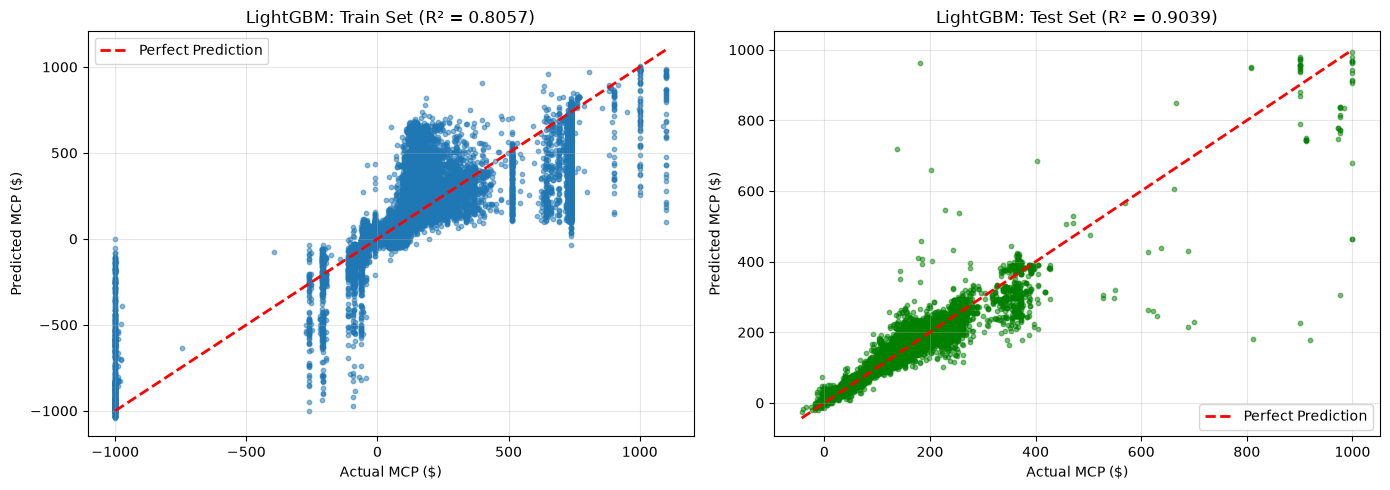

In [18]:
import matplotlib.pyplot as plt

# Create actual vs predicted plots for LightGBM
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train set plot
axes[0].scatter(y_train, y_train_pred, alpha=0.5, s=10)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual MCP ($)')
axes[0].set_ylabel('Predicted MCP ($)')
axes[0].set_title(f'LightGBM: Train Set (R² = {train_r2:.4f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Test set plot
axes[1].scatter(y_test, y_test_pred, alpha=0.5, s=10, color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual MCP ($)')
axes[1].set_ylabel('Predicted MCP ($)')
axes[1].set_title(f'LightGBM: Test Set (R² = {test_r2:.4f})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Computing SHAP values for feature interpretation...


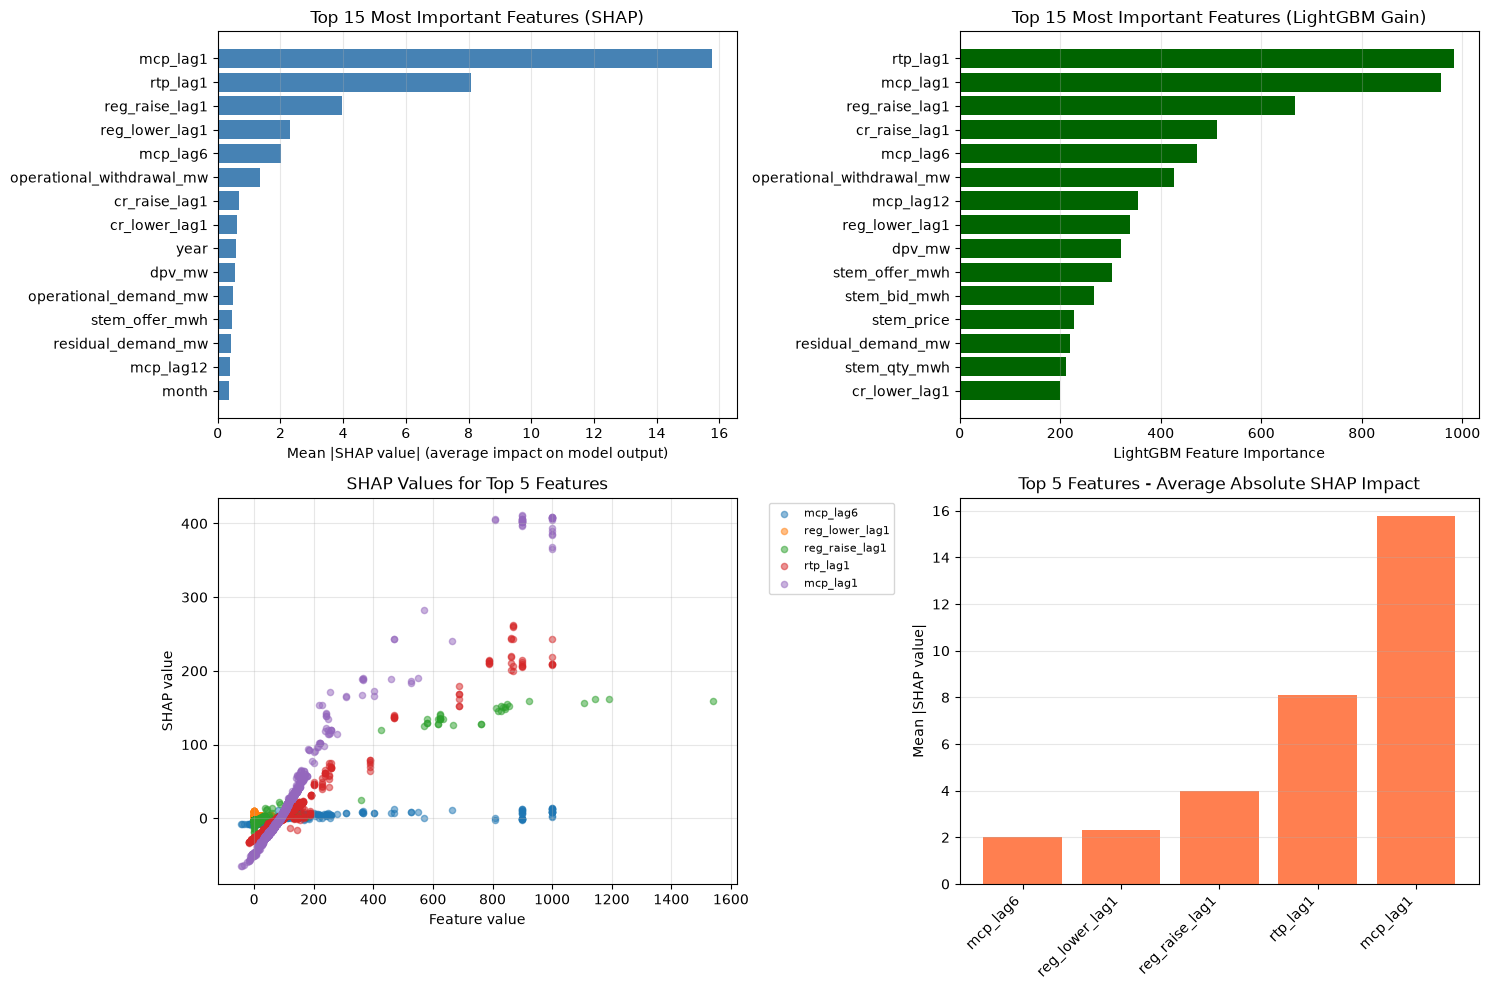


SHAP Feature Importance Summary

Top 10 Most Important Features (by mean |SHAP|):
                  Feature  Mean |SHAP|  LightGBM Importance
                 mcp_lag1    15.776211                  958
                 rtp_lag1     8.093174                  984
           reg_raise_lag1     3.970347                  667
           reg_lower_lag1     2.309817                  338
                 mcp_lag6     2.009333                  472
operational_withdrawal_mw     1.333918                  426
            cr_raise_lag1     0.684174                  512
            cr_lower_lag1     0.617993                  200
                     year     0.581500                  128
                   dpv_mw     0.558483                  321


In [9]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Get the trained LightGBM model
best_model = random_search.best_estimator_

# Create SHAP explainer using TreeExplainer (fast for tree-based models)
print("Computing SHAP values for feature interpretation...")
explainer = shap.TreeExplainer(best_model)

# Calculate SHAP values for test set (using subset to speed up computation)
shap_values_test = explainer.shap_values(X_test.iloc[:5000])  # Use subset for speed

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Feature importance bar plot (mean absolute SHAP values)
mean_abs_shap = np.abs(shap_values_test).mean(axis=0)
feature_importance_df = pd.DataFrame({
    'Feature': FEATURES,
    'Mean |SHAP|': mean_abs_shap
}).sort_values('Mean |SHAP|', ascending=True).tail(15)

axes[0, 0].barh(feature_importance_df['Feature'], feature_importance_df['Mean |SHAP|'], color='steelblue')
axes[0, 0].set_xlabel('Mean |SHAP value| (average impact on model output)')
axes[0, 0].set_title('Top 15 Most Important Features (SHAP)')
axes[0, 0].grid(True, alpha=0.3, axis='x')

# 2. Builtin feature importance from LightGBM
feature_importance_lgb = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=True).tail(15)

axes[0, 1].barh(feature_importance_lgb['Feature'], feature_importance_lgb['Importance'], color='darkgreen')
axes[0, 1].set_xlabel('LightGBM Feature Importance')
axes[0, 1].set_title('Top 15 Most Important Features (LightGBM Gain)')
axes[0, 1].grid(True, alpha=0.3, axis='x')

# 3. Summary plot data - prepare for visualization
top_features_idx = np.argsort(mean_abs_shap)[-10:]  # Top 10 features
top_features = [FEATURES[i] for i in top_features_idx]

# Create a simpler summary scatter for top features
for idx, feature_idx in enumerate(top_features_idx[-5:]):  # Show top 5
    feature_name = FEATURES[feature_idx]
    shap_vals = shap_values_test[:, feature_idx]
    feature_vals = X_test.iloc[:5000, feature_idx].values
    
    scatter = axes[1, 0].scatter(feature_vals, shap_vals, alpha=0.5, s=20, label=feature_name)

axes[1, 0].set_ylabel('SHAP value')
axes[1, 0].set_xlabel('Feature value')
axes[1, 0].set_title('SHAP Values for Top 5 Features')
axes[1, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

# 4. Feature contribution comparison for top 5 features
top_5_features = [FEATURES[i] for i in np.argsort(mean_abs_shap)[-5:]]
top_5_indices = [FEATURES.index(f) for f in top_5_features]
top_5_means = [mean_abs_shap[i] for i in top_5_indices]

axes[1, 1].bar(range(len(top_5_features)), top_5_means, color='coral')
axes[1, 1].set_xticks(range(len(top_5_features)))
axes[1, 1].set_xticklabels(top_5_features, rotation=45, ha='right')
axes[1, 1].set_ylabel('Mean |SHAP value|')
axes[1, 1].set_title('Top 5 Features - Average Absolute SHAP Impact')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("SHAP Feature Importance Summary")
print("="*60)
print("\nTop 10 Most Important Features (by mean |SHAP|):")
top_10_importance = pd.DataFrame({
    'Feature': [FEATURES[i] for i in np.argsort(mean_abs_shap)[-10:][::-1]],
    'Mean |SHAP|': np.sort(mean_abs_shap)[-10:][::-1],
    'LightGBM Importance': [best_model.feature_importances_[FEATURES.index(f)] 
                            for f in [FEATURES[i] for i in np.argsort(mean_abs_shap)[-10:][::-1]]]
})
print(top_10_importance.to_string(index=False))


Generating SHAP Summary Plot...


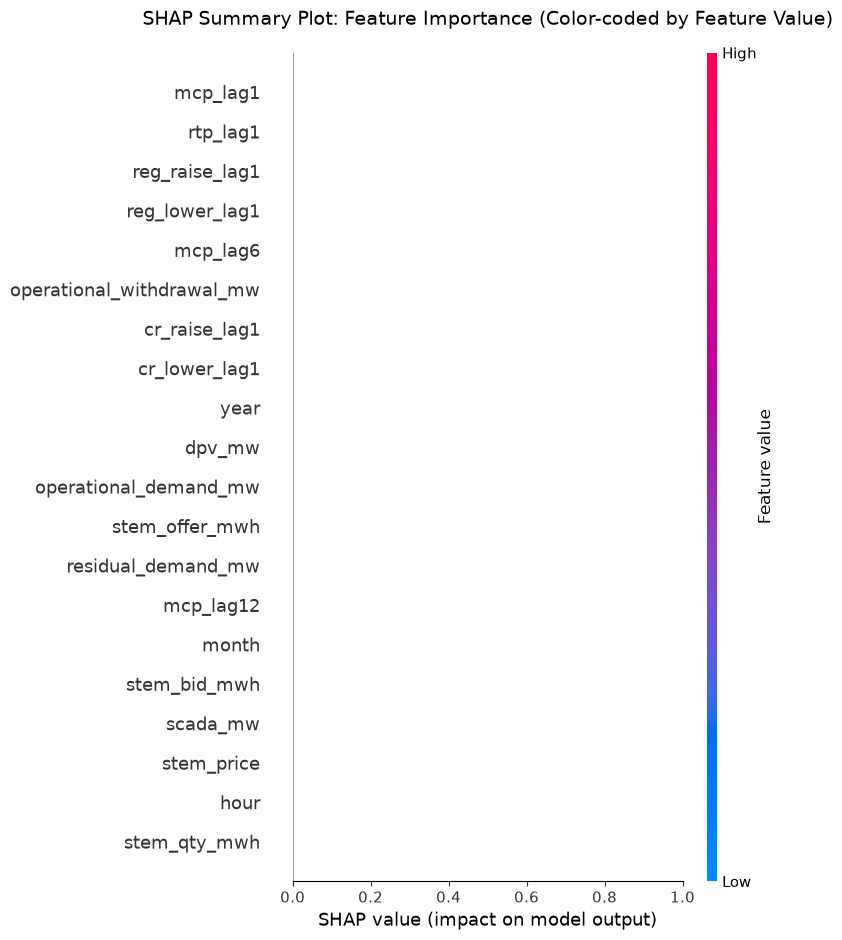


SHAP Summary Plot Complete!
- X-axis: SHAP value (impact on model output)
- Y-axis: Features (ordered by importance)
- Color: Feature value (blue=low, red=high)
- Position: Dots show individual prediction impacts


In [10]:
# Create SHAP Summary Plot (color-coded beeswarm)
print("\nGenerating SHAP Summary Plot...")

# Create figure with summary plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_test, X_test.iloc[:5000], plot_type="beeswarm", show=False)
plt.title('SHAP Summary Plot: Feature Importance (Color-coded by Feature Value)', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print("\nSHAP Summary Plot Complete!")
print("- X-axis: SHAP value (impact on model output)")
print("- Y-axis: Features (ordered by importance)")
print("- Color: Feature value (blue=low, red=high)")
print("- Position: Dots show individual prediction impacts")